# Machine Learning Techniques Guide
## A Comprehensive Introduction to Supervised and Unsupervised Learning

### Overview
This notebook provides a holistic introduction to four fundamental machine learning techniques used in data analysis:

1. **Logistic Regression** - A supervised learning algorithm for binary and multi-class classification
2. **K-Nearest Neighbors (KNN)** - A simple yet powerful supervised learning algorithm for classification
3. **K-Means Clustering** - An unsupervised learning algorithm for partitioning data into clusters
4. **Hierarchical Clustering** - An unsupervised learning algorithm that creates a tree of clusters

### Dataset
We'll use the **Iris Dataset**, a classic dataset in machine learning containing measurements of iris flowers. This dataset is perfect for understanding these techniques because:
- It has 150 samples of iris flowers
- Contains 4 numerical features: sepal length, sepal width, petal length, petal width
- Has 3 classes/species: Setosa, Versicolor, Virginica
- Works well for both classification and clustering tasks

### Learning Path
- First two sections cover **supervised learning** (we have labeled data)
- Last two sections cover **unsupervised learning** (we find patterns without labels)
- Each section includes conceptual explanation, code implementation, and visualizations

### Key Concepts You'll Learn
- How to prepare and explore data
- How to train and evaluate machine learning models
- How to visualize decision boundaries and clusters
- When to use each technique and why
- How to interpret results and make predictions

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Part 0: Data Loading and Exploration

In [3]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: species (0=Setosa, 1=Versicolor, 2=Virginica)

# Create a DataFrame for easier exploration
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[y]
iris_df['Target'] = y

# Display first few rows
print("Dataset Overview:")
print(iris_df.head())
print(f"\nDataset Shape: {iris_df.shape}")
print(f"\nDataset Info:")
print(iris_df.info())
print(f"\nClass Distribution:")
print(iris_df['Species'].value_counts())

Dataset Overview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  Target  
0  setosa       0  
1  setosa       0  
2  setosa       0  
3  setosa       0  
4  setosa       0  

Dataset Shape: (150, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3 

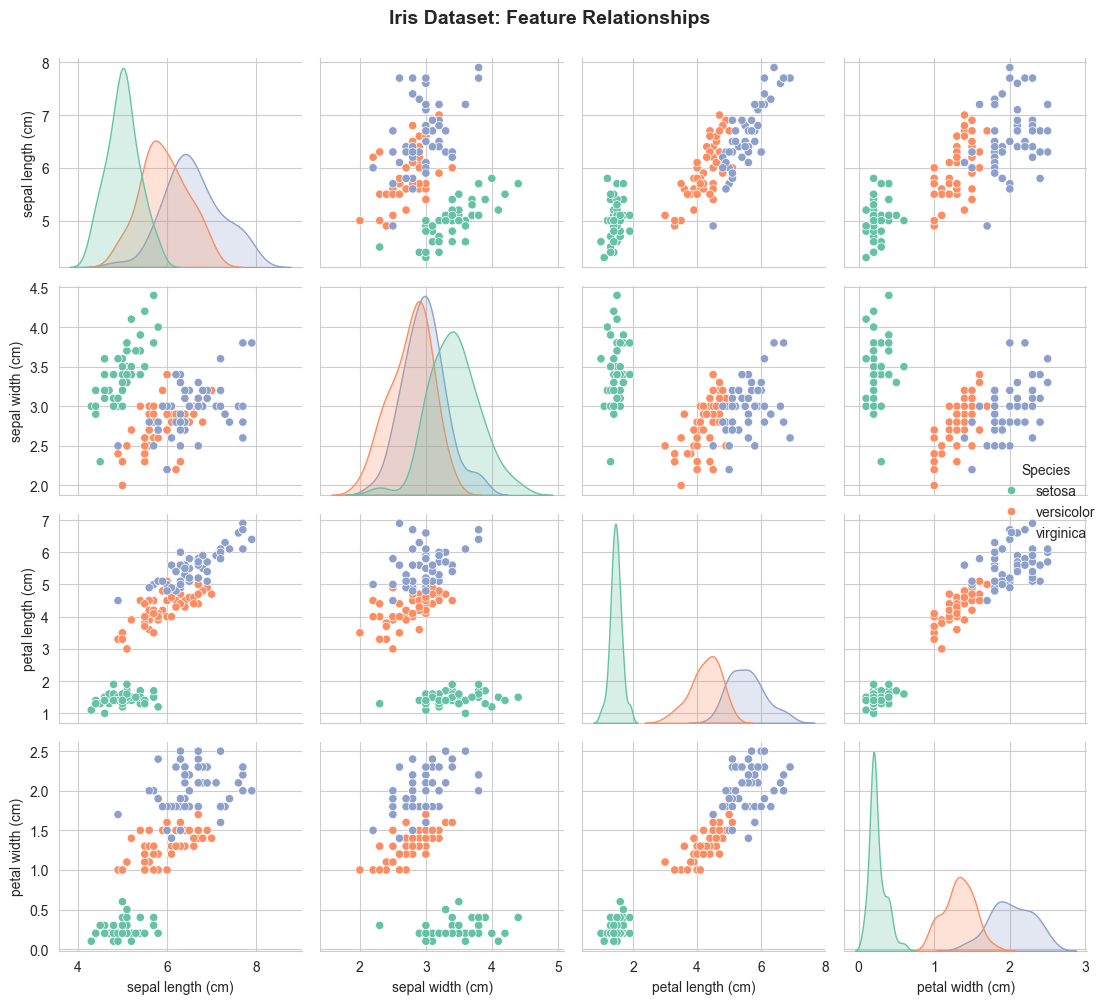


Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      Target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [4]:
# Visualize the dataset with pairplot
# Create a pairplot without the Target column (numeric version of species)
plot_df = iris_df.drop('Target', axis=1)
g = sns.pairplot(plot_df, hue='Species', diag_kind='kde', palette='Set2')
g.fig.suptitle('Iris Dataset: Feature Relationships', y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display basic statistics
print("\nDataset Statistics:")
print(iris_df.describe())

In [8]:
# Standardize the features (important for distance-based algorithms)
# This scales features to have mean=0 and standard deviation=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nFeatures shape: {X_train.shape[1]}")

Training set size: 90
Testing set size: 60

Features shape: 4


---
## Part 1: Logistic Regression

### What is Logistic Regression?

**Definition:** Logistic Regression is a supervised learning algorithm used for binary and multi-class classification problems. Despite its name, it's a classification algorithm, not a regression algorithm.

### How It Works

1. **Core Idea:** Logistic regression fits a logistic function (S-shaped curve) to the data
2. **Output:** Produces probability scores between 0 and 1 for each class
3. **Decision Rule:** Classes are assigned based on probability thresholds

### Mathematical Intuition

The logistic function transforms linear combinations of features into probabilities:

$$P(y=1|x) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Where:
- $w$ = weights for each feature
- $x$ = input features
- $b$ = bias term
- The output is always between 0 and 1 (probability)

### When to Use
- Binary or multi-class classification problems
- When you need probability estimates
- When interpretability is important (you can see feature weights)
- When data is approximately linearly separable

### Advantages & Disadvantages

✓ **Advantages:**
- Fast and efficient
- Interpretable results
- Works well with linearly separable data

✗ **Disadvantages:**
- Assumes linear relationship between features and outcome
- Poor performance on highly non-linear data

In [9]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate accuracy
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Training Accuracy: {train_accuracy_lr:.4f} ({train_accuracy_lr*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy_lr:.4f} ({test_accuracy_lr*100:.2f}%)")
print(f"\nModel Coefficients (Feature Importance):")
print("-"*50)
for i, feature_name in enumerate(iris.feature_names):
    print(f"{feature_name}: {lr_model.coef_[0][i]:.4f}")

LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.9667 (96.67%)
Testing Accuracy: 0.9833 (98.33%)

Model Coefficients (Feature Importance):
--------------------------------------------------
sepal length (cm): -0.9344
sepal width (cm): 0.9906
petal length (cm): -1.6600
petal width (cm): -1.5574


In [10]:
# Detailed classification report
print("\nClassification Report (Test Set):")
print("="*50)
print(classification_report(y_test, y_test_pred_lr, target_names=iris.target_names))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)


Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        23
  versicolor       0.95      1.00      0.97        19
   virginica       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
[[23  0  0]
 [ 0 19  0]
 [ 0  1 17]]


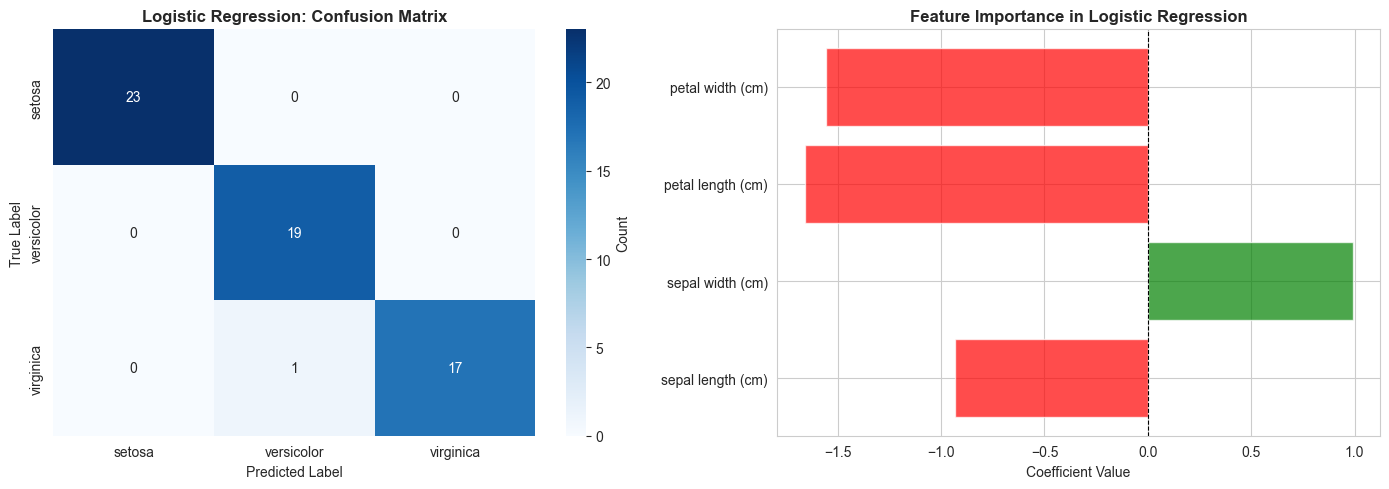

Interpretation:
- Confusion Matrix: Shows correct (diagonal) vs incorrect predictions
- Feature Importance: Positive values increase probability, negative decrease it


In [11]:
# Visualize Logistic Regression Results

# 1. Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Logistic Regression: Confusion Matrix', fontweight='bold')

# Feature Coefficients (Importance)
coefficients = lr_model.coef_[0]
colors = ['green' if x > 0 else 'red' for x in coefficients]
axes[1].barh(iris.feature_names, coefficients, color=colors, alpha=0.7)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Feature Importance in Logistic Regression', fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Confusion Matrix: Shows correct (diagonal) vs incorrect predictions")
print("- Feature Importance: Positive values increase probability, negative decrease it")

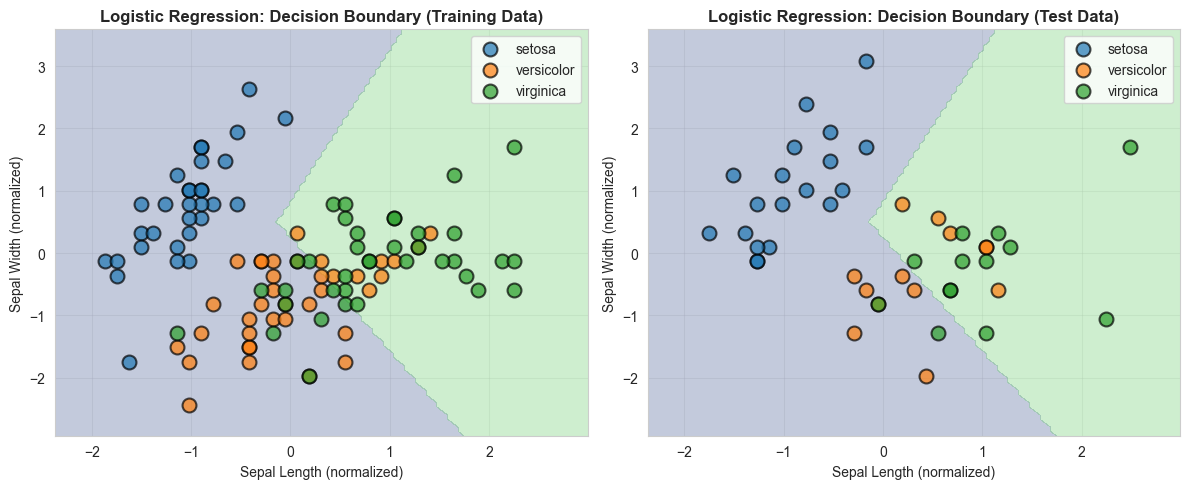


2D Model Accuracy: 0.8222
The colored regions show where each class is predicted by the model.
Decision boundaries are the lines separating different colored regions.


In [12]:
# Visualize decision boundaries using first two features
# This helps understand how logistic regression separates classes

# We'll focus on the first two features for 2D visualization
X_2d = X_scaled[:, :2]  # Use only sepal length and sepal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42)

# Train model on 2D data
lr_model_2d = LogisticRegression(max_iter=200, random_state=42)
lr_model_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid for decision boundary
xx, yy = np.meshgrid(np.linspace(X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5, 100),
                     np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 100))
Z = lr_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 5))

# Plot 1: Training data with decision boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(3), cmap='viridis')
for i, target in enumerate(np.unique(y_train_2d)):
    plt.scatter(X_train_2d[y_train_2d == target, 0],
               X_train_2d[y_train_2d == target, 1],
               label=iris.target_names[target],
               s=100, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('Logistic Regression: Decision Boundary (Training Data)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test data predictions
plt.subplot(1, 2, 2)
y_test_pred_2d = lr_model_2d.predict(X_test_2d)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(3), cmap='viridis')
for i, target in enumerate(np.unique(y_test_2d)):
    plt.scatter(X_test_2d[y_test_2d == target, 0],
               X_test_2d[y_test_2d == target, 1],
               label=iris.target_names[target],
               s=100, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('Logistic Regression: Decision Boundary (Test Data)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n2D Model Accuracy: {lr_model_2d.score(X_test_2d, y_test_2d):.4f}")
print("The colored regions show where each class is predicted by the model.")
print("Decision boundaries are the lines separating different colored regions.")

---
## Part 2: K-Nearest Neighbors (KNN)

### What is K-Nearest Neighbors?

**Definition:** KNN is a simple supervised learning algorithm that classifies data points based on the classes of their k nearest neighbors in the feature space.

### How It Works

1. **Store all training data** (lazy learner - no training phase)
2. **For a new point:** Calculate distance to all training points
3. **Find k nearest neighbors** using distance metric (typically Euclidean)
4. **Vote:** Assign the most common class among those k neighbors

### Key Considerations

**Choosing k:**
- Small k (1-5): Model is flexible but sensitive to noise
- Large k: Model is more stable but may miss fine details
- Typically use odd numbers to avoid ties in binary classification

**Distance Metric (Euclidean):**
$$d(p,q) = \sqrt{(p_1-q_1)^2 + (p_2-q_2)^2 + ... + (p_n-q_n)^2}$$

### When to Use
- Non-linear classification problems
- Small to medium-sized datasets
- When no specific model has worked well
- For baseline comparisons

### Advantages & Disadvantages

✓ **Advantages:**
- Simple to understand and implement
- Works well with non-linear data
- No training phase (can adapt quickly to new data)

✗ **Disadvantages:**
- Slow prediction time (must check distance to all training points)
- Sensitive to feature scaling (requires standardization)
- High memory usage (stores all training data)
- Sensitive to irrelevant features

In [13]:
# Test different values of k to find the optimal one
k_values = range(1, 21)
train_accuracies_knn = []
test_accuracies_knn = []

# Train KNN models with different k values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    train_accuracies_knn.append(train_acc)
    test_accuracies_knn.append(test_acc)

# Find optimal k
optimal_k = k_values[np.argmax(test_accuracies_knn)]
print(f"Optimal k value: {optimal_k}")
print(f"Test accuracy with k={optimal_k}: {max(test_accuracies_knn):.4f}")

Optimal k value: 3
Test accuracy with k=3: 0.9833


In [14]:
# Train final KNN model with optimal k
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train, y_train)

# Make predictions
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

# Calculate accuracy
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

print("KNN RESULTS (k=" + str(optimal_k) + ")")
print("="*50)
print(f"Training Accuracy: {train_accuracy_knn:.4f} ({train_accuracy_knn*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy_knn:.4f} ({test_accuracy_knn*100:.2f}%)")

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
print("\nConfusion Matrix:")
print(cm_knn)

KNN RESULTS (k=3)
Training Accuracy: 0.9444 (94.44%)
Testing Accuracy: 0.9833 (98.33%)

Confusion Matrix:
[[23  0  0]
 [ 0 19  0]
 [ 0  1 17]]


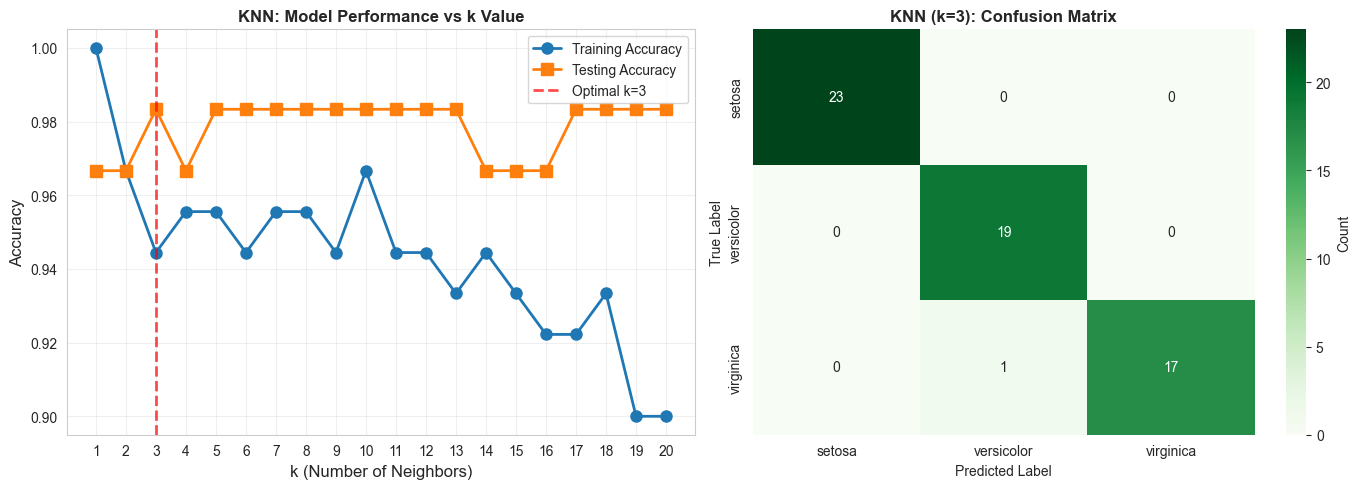


Interpretation:
- The left plot shows how accuracy changes with different k values
- k=3 was chosen because it maximizes test accuracy
- k=1 often shows high training accuracy but lower test accuracy (overfitting)


In [15]:
# Visualize KNN Results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs k value
axes[0].plot(k_values, train_accuracies_knn, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
axes[0].plot(k_values, test_accuracies_knn, 's-', label='Testing Accuracy', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal k={optimal_k}')
axes[0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('KNN: Model Performance vs k Value', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 21))

# Plot 2: Confusion Matrix for optimal k
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            cbar_kws={'label': 'Count'})
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_title(f'KNN (k={optimal_k}): Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"- The left plot shows how accuracy changes with different k values")
print(f"- k={optimal_k} was chosen because it maximizes test accuracy")
print(f"- k=1 often shows high training accuracy but lower test accuracy (overfitting)")

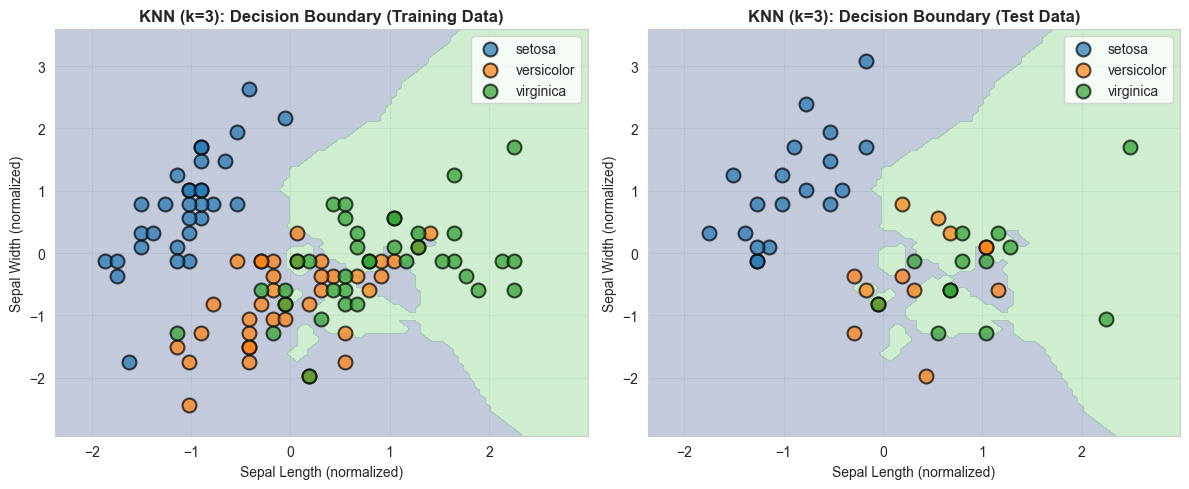


Observations:
- KNN creates more complex, localized decision boundaries compared to Logistic Regression
- The boundaries follow the data points more closely
- This allows KNN to capture non-linear patterns


In [16]:
# Visualize KNN decision boundaries
# Train KNN on 2D data
knn_model_2d = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid for decision boundary
xx, yy = np.meshgrid(np.linspace(X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5, 100),
                     np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 100))
Z = knn_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 5))

# Plot 1: Training data
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(3), cmap='viridis')
for i, target in enumerate(np.unique(y_train_2d)):
    plt.scatter(X_train_2d[y_train_2d == target, 0],
               X_train_2d[y_train_2d == target, 1],
               label=iris.target_names[target],
               s=100, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title(f'KNN (k={optimal_k}): Decision Boundary (Training Data)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test data
plt.subplot(1, 2, 2)
y_test_pred_2d_knn = knn_model_2d.predict(X_test_2d)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(3), cmap='viridis')
for i, target in enumerate(np.unique(y_test_2d)):
    plt.scatter(X_test_2d[y_test_2d == target, 0],
               X_test_2d[y_test_2d == target, 1],
               label=iris.target_names[target],
               s=100, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title(f'KNN (k={optimal_k}): Decision Boundary (Test Data)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nObservations:")
print(f"- KNN creates more complex, localized decision boundaries compared to Logistic Regression")
print(f"- The boundaries follow the data points more closely")
print(f"- This allows KNN to capture non-linear patterns")

---
## Part 3: K-Means Clustering

### What is K-Means Clustering?

**Definition:** K-Means is an unsupervised learning algorithm that partitions data into k clusters, where each cluster contains data points that are similar to each other.

**Key Difference:** Unlike Logistic Regression and KNN, K-Means doesn't use labeled data. It discovers patterns by itself!

### How It Works

**Algorithm Steps:**
1. **Initialize:** Randomly select k points as initial cluster centers (centroids)
2. **Assign:** Assign each point to the nearest centroid (using distance)
3. **Update:** Recalculate centroids as the mean of all points in each cluster
4. **Repeat:** Steps 2-3 until centroids don't change (convergence)

### Choosing k

Determining the number of clusters is crucial:
- **Elbow Method:** Plot inertia vs k and look for the "elbow" point
- **Silhouette Score:** Measures how similar a point is to its cluster
- **Domain Knowledge:** Use what you know about the data

### When to Use
- Discovering natural groupings in data
- No labeled data available
- Customer segmentation
- Image compression
- Gene sequencing

### Advantages & Disadvantages

✓ **Advantages:**
- Simple and fast
- Scales well to large datasets
- Easy to implement

✗ **Disadvantages:**
- Must specify k in advance
- Sensitive to initial centroid placement
- Assumes spherical clusters
- Sensitive to outliers
- May converge to local optima

In [17]:
# Use the Elbow Method to find optimal k for K-Means
inertias = []
silhouette_scores = []
k_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Display results
print("K-Means: Elbow Method Analysis")
print("="*50)
for k, inertia, sil_score in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette Score={sil_score:.4f}")

# Find optimal k using silhouette score
optimal_k_kmeans = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k (by Silhouette Score): {optimal_k_kmeans}")

K-Means: Elbow Method Analysis
k=2: Inertia=222.36, Silhouette Score=0.5818
k=3: Inertia=139.82, Silhouette Score=0.4599
k=4: Inertia=114.09, Silhouette Score=0.3869
k=5: Inertia=90.93, Silhouette Score=0.3459
k=6: Inertia=81.54, Silhouette Score=0.3171
k=7: Inertia=72.63, Silhouette Score=0.3202
k=8: Inertia=62.54, Silhouette Score=0.3387
k=9: Inertia=55.12, Silhouette Score=0.3424
k=10: Inertia=47.39, Silhouette Score=0.3518

Optimal k (by Silhouette Score): 2


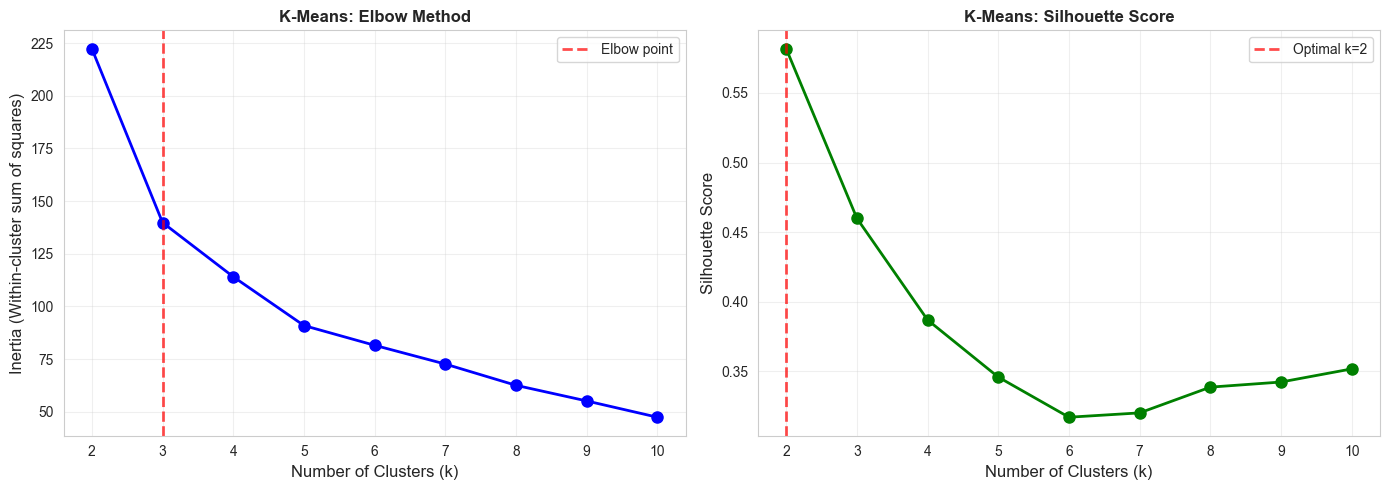


Interpretation:
- Left: Elbow curve shows where adding more clusters provides less benefit
- Right: Silhouette score measures cluster cohesion (higher is better)
- For Iris dataset, k=3 is optimal (matches the 3 iris species!)


In [18]:
# Visualize Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Curve (Inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('K-Means: Elbow Method', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Elbow point')
axes[0].legend()

# Plot 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k_kmeans, color='red', linestyle='--', alpha=0.7, linewidth=2,
                label=f'Optimal k={optimal_k_kmeans}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('K-Means: Silhouette Score', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Left: Elbow curve shows where adding more clusters provides less benefit")
print("- Right: Silhouette score measures cluster cohesion (higher is better)")
print("- For Iris dataset, k=3 is optimal (matches the 3 iris species!)")

In [19]:
# Train K-Means with optimal k
# Note: We use k=3 because it matches the actual number of iris species
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_clusters = kmeans_model.fit_predict(X_scaled)

# Get cluster centers
cluster_centers = kmeans_model.cluster_centers_
inertia = kmeans_model.inertia_

print("K-MEANS CLUSTERING RESULTS (k=3)")
print("="*50)
print(f"Inertia (sum of squared distances): {inertia:.4f}")
print(f"Number of iterations: {kmeans_model.n_iter_}")
print(f"\nCluster Sizes:")
for i in range(3):
    cluster_size = np.sum(kmeans_clusters == i)
    print(f"  Cluster {i}: {cluster_size} points")

K-MEANS CLUSTERING RESULTS (k=3)
Inertia (sum of squared distances): 139.8205
Number of iterations: 4

Cluster Sizes:
  Cluster 0: 53 points
  Cluster 1: 50 points
  Cluster 2: 47 points


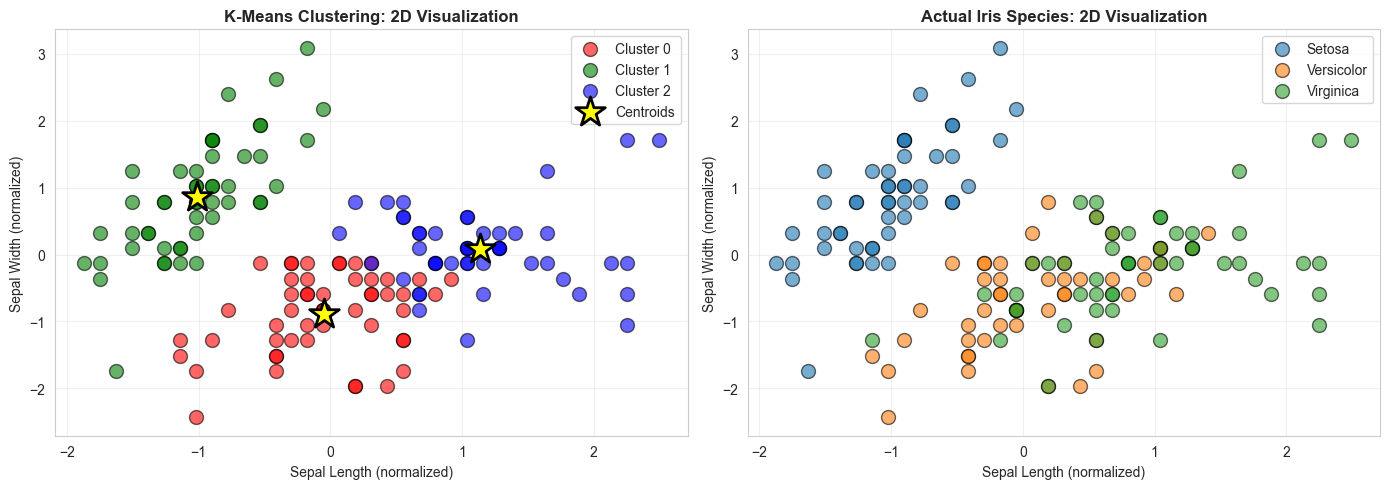

Observation: K-Means discovers clusters that often align with actual species,
despite not having seen the true labels during training!


In [20]:
# Visualize K-Means Clustering on 2D projection
plt.figure(figsize=(14, 5))

# Plot 1: K-Means Clusters
plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i in range(3):
    cluster_points = X_2d[kmeans_clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=colors[i], label=f'Cluster {i}', s=100, alpha=0.6, edgecolor='black', linewidth=1)

# Plot cluster centers
centers_2d = cluster_centers[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c='yellow', marker='*', s=500, edgecolor='black', linewidth=2,
           label='Centroids')
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('K-Means Clustering: 2D Visualization', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: K-Means vs Actual Species
plt.subplot(1, 2, 2)
species_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
for i, species in enumerate([0, 1, 2]):
    species_points = X_2d[y == species]
    plt.scatter(species_points[:, 0], species_points[:, 1],
               label=species_names[species], s=100, alpha=0.6, edgecolor='black', linewidth=1)
plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('Actual Iris Species: 2D Visualization', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: K-Means discovers clusters that often align with actual species,")
print("despite not having seen the true labels during training!")

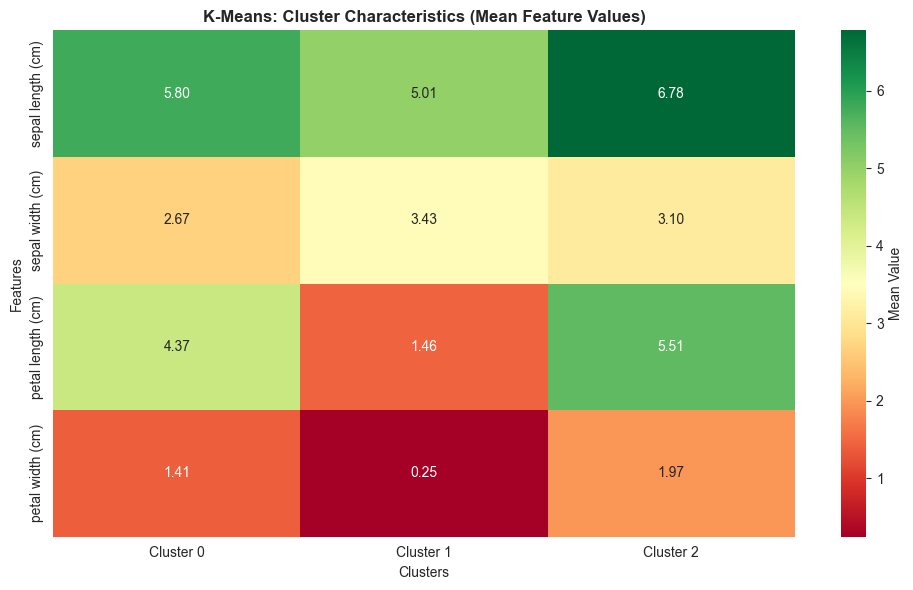


Cluster Characteristics:
                   Cluster 0  Cluster 1  Cluster 2
sepal length (cm)   5.801887      5.006   6.780851
sepal width (cm)    2.673585      3.428   3.095745
petal length (cm)   4.369811      1.462   5.510638
petal width (cm)    1.413208      0.246   1.972340

Interpretation:
- Each cluster has distinct feature patterns
- Cluster 0: Small flowers (likely Setosa)
- Clusters 1,2: Larger flowers with different characteristics


In [21]:
# Visualize cluster characteristics
# Calculate mean feature values for each cluster
cluster_means = pd.DataFrame()
for i in range(3):
    cluster_mask = kmeans_clusters == i
    cluster_means[f'Cluster {i}'] = X[cluster_mask].mean(axis=0)

cluster_means.index = iris.feature_names

# Visualize cluster characteristics as heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Mean Value'})
plt.title('K-Means: Cluster Characteristics (Mean Feature Values)', fontweight='bold')
plt.ylabel('Features')
plt.xlabel('Clusters')
plt.tight_layout()
plt.show()

print("\nCluster Characteristics:")
print(cluster_means)
print("\nInterpretation:")
print("- Each cluster has distinct feature patterns")
print("- Cluster 0: Small flowers (likely Setosa)")
print("- Clusters 1,2: Larger flowers with different characteristics")

---
## Part 4: Hierarchical Clustering

### What is Hierarchical Clustering?

**Definition:** Hierarchical Clustering is an unsupervised learning algorithm that builds a hierarchy of clusters, represented as a tree (dendrogram).

**Two Approaches:**
1. **Agglomerative (Bottom-up):** Start with each point as a cluster, merge closest clusters
2. **Divisive (Top-down):** Start with all points in one cluster, split recursively

### How It Works (Agglomerative)

**Algorithm Steps:**
1. **Start:** Each data point is its own cluster (n clusters for n points)
2. **Merge:** Find two closest clusters based on linkage criterion
3. **Repeat:** Continue merging until all points are in one cluster
4. **Result:** Tree structure showing merge history

### Linkage Methods

Different ways to measure distance between clusters:
- **Single Linkage:** Minimum distance between clusters (can create chains)
- **Complete Linkage:** Maximum distance between clusters (tight clusters)
- **Average Linkage:** Average distance between elements (balanced)
- **Ward:** Minimizes variance within clusters (most commonly used)

### When to Use
- Need visual representation of hierarchical relationships
- Number of clusters not known a priori
- Want to explore multiple cluster levels
- Dealing with hierarchical data

### Advantages & Disadvantages

✓ **Advantages:**
- Dendrogram provides intuitive visualization
- Don't need to specify k in advance (but do to cut tree)
- Reveals hierarchical structure of data

✗ **Disadvantages:**
- Computationally expensive (O(n²) or O(n³))
- Once clusters merged, can't separate them (irreversible)
- Sensitive to noise and outliers
- Slow on large datasets

In [22]:
# Perform hierarchical clustering using Ward linkage
# Ward minimizes variance within clusters
Z = linkage(X_scaled, method='ward')

print("Hierarchical Clustering: Linkage Matrix")
print("="*50)
print(f"Shape: {Z.shape}")
print(f"\nLinkage matrix dimensions:")
print(f"  - Rows: {Z.shape[0]} (number of merge operations)")
print(f"  - Columns: 4")
print(f"    Column 0: Index of first cluster merged")
print(f"    Column 1: Index of second cluster merged")
print(f"    Column 2: Distance between merged clusters")
print(f"    Column 3: Number of samples in merged cluster")
print(f"\nFirst 10 merge operations:")
print(Z[:10])

Hierarchical Clustering: Linkage Matrix
Shape: (149, 4)

Linkage matrix dimensions:
  - Rows: 149 (number of merge operations)
  - Columns: 4
    Column 0: Index of first cluster merged
    Column 1: Index of second cluster merged
    Column 2: Distance between merged clusters
    Column 3: Number of samples in merged cluster

First 10 merge operations:
[[1.01000000e+02 1.42000000e+02 0.00000000e+00 2.00000000e+00]
 [7.00000000e+00 3.90000000e+01 1.21167870e-01 2.00000000e+00]
 [1.00000000e+01 4.80000000e+01 1.21167870e-01 2.00000000e+00]
 [0.00000000e+00 1.70000000e+01 1.31632184e-01 2.00000000e+00]
 [9.00000000e+00 3.40000000e+01 1.31632184e-01 2.00000000e+00]
 [1.28000000e+02 1.32000000e+02 1.31632184e-01 2.00000000e+00]
 [1.27000000e+02 1.38000000e+02 1.33836265e-01 2.00000000e+00]
 [2.00000000e+00 4.70000000e+01 1.33836265e-01 2.00000000e+00]
 [1.90000000e+01 4.60000000e+01 1.43378956e-01 2.00000000e+00]
 [8.00000000e+01 8.10000000e+01 1.43378956e-01 2.00000000e+00]]


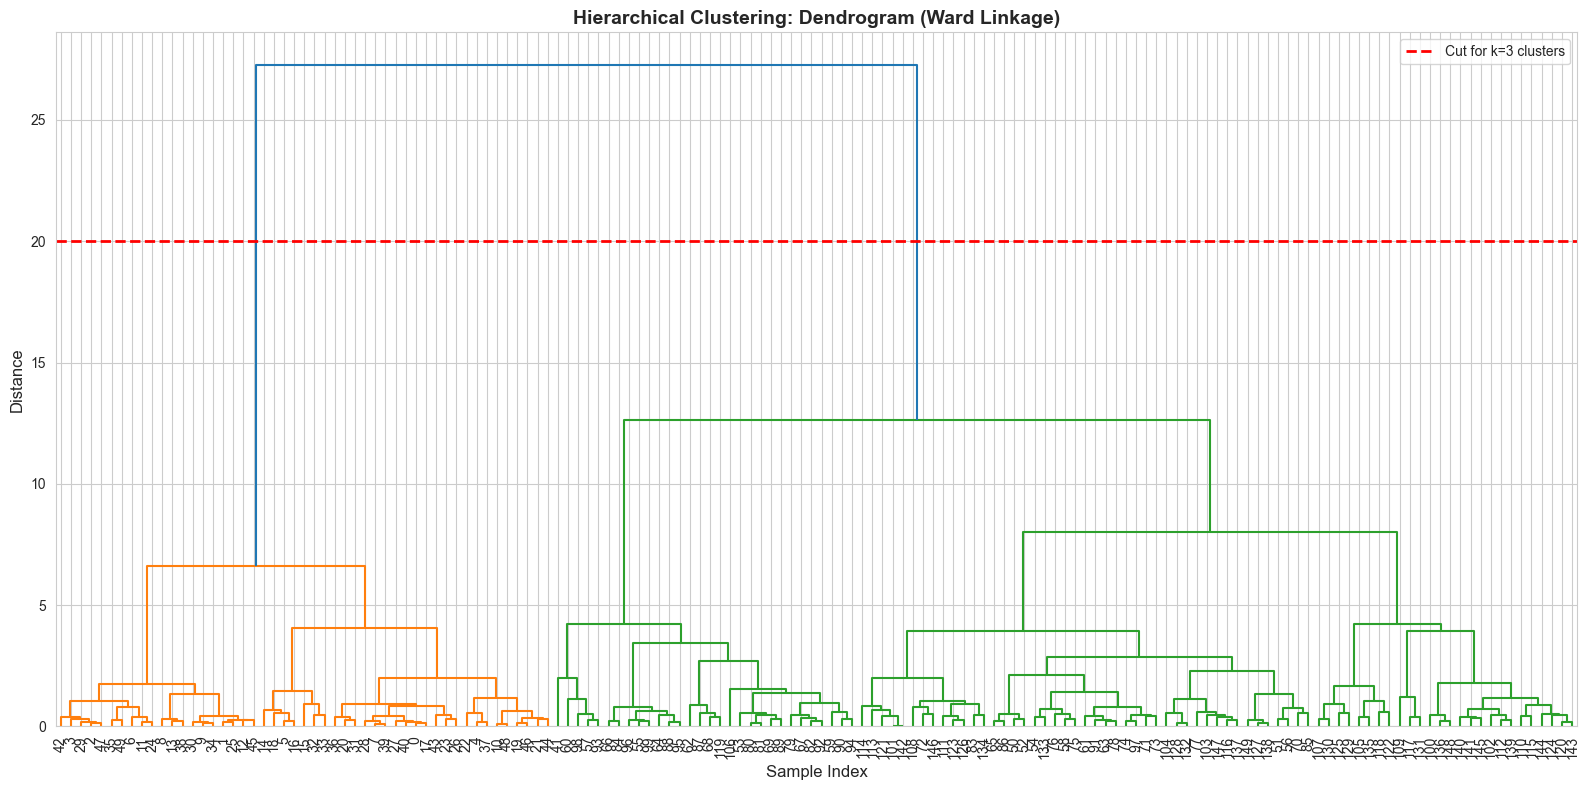


Dendrogram Interpretation:
- X-axis: Individual data points
- Y-axis: Distance (how dissimilar clusters were when merged)
- Horizontal lines: Merge events
- Height of line: Dissimilarity of merged clusters
- Red line: Cutting point for k=3 clusters


In [21]:
# Visualize dendrogram
plt.figure(figsize=(16, 8))
dendrogram(Z, labels=None, leaf_font_size=10)
plt.title('Hierarchical Clustering: Dendrogram (Ward Linkage)', fontweight='bold', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=20, color='r', linestyle='--', linewidth=2, label='Cut for k=3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

print("\nDendrogram Interpretation:")
print("- X-axis: Individual data points")
print("- Y-axis: Distance (how dissimilar clusters were when merged)")
print("- Horizontal lines: Merge events")
print("- Height of line: Dissimilarity of merged clusters")
print("- Red line: Cutting point for k=3 clusters")

In [23]:
# Perform hierarchical clustering with cut to form k=3 clusters
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_clusters = hierarchical_model.fit_predict(X_scaled)

print("HIERARCHICAL CLUSTERING RESULTS (k=3)")
print("="*50)
print(f"Cluster Distribution:")
for i in range(3):
    cluster_size = np.sum(hierarchical_clusters == i)
    print(f"  Cluster {i}: {cluster_size} points")

HIERARCHICAL CLUSTERING RESULTS (k=3)
Cluster Distribution:
  Cluster 0: 71 points
  Cluster 1: 49 points
  Cluster 2: 30 points


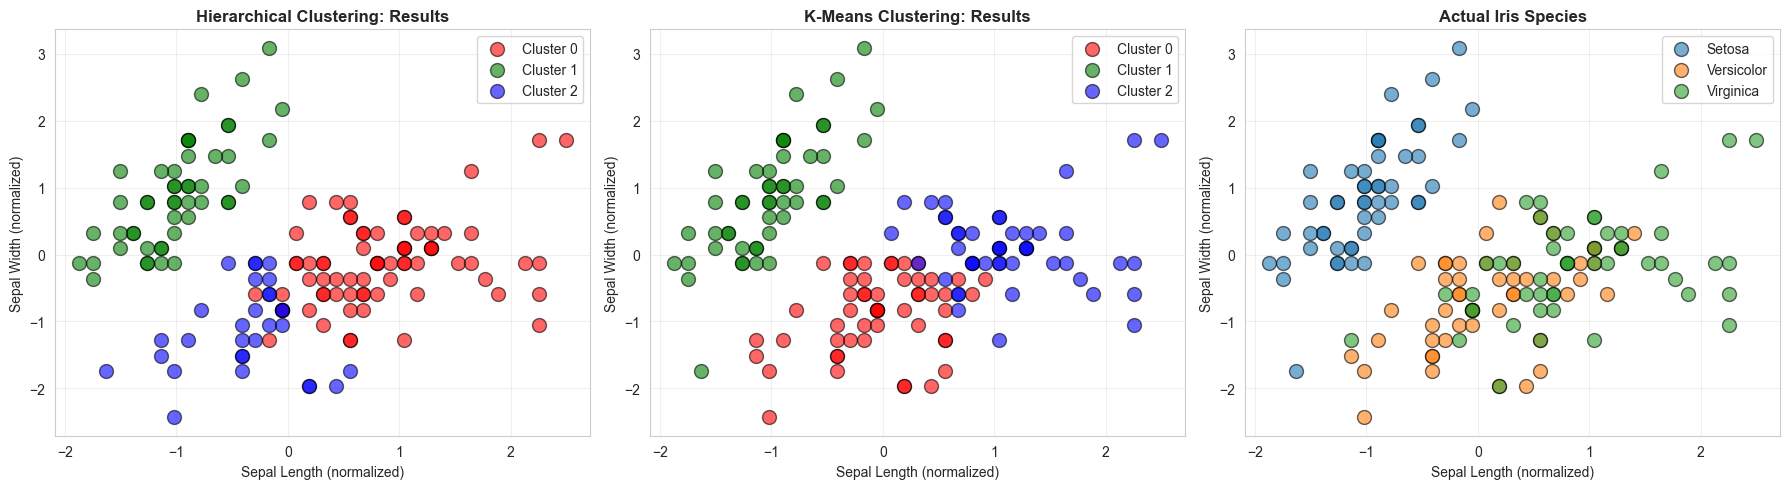


Comparison:
- Both K-Means and Hierarchical Clustering discover similar cluster structures
- Both unsupervised methods can find the natural groupings in the data
- Hierarchical clustering additionally provides a dendrogram showing relationships


In [24]:
# Compare hierarchical clustering with K-Means and actual labels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hierarchical Clusters
colors = ['red', 'green', 'blue']
for i in range(3):
    cluster_points = X_2d[hierarchical_clusters == i]
    axes[0].scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c=colors[i], label=f'Cluster {i}', s=100, alpha=0.6, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Sepal Length (normalized)')
axes[0].set_ylabel('Sepal Width (normalized)')
axes[0].set_title('Hierarchical Clustering: Results', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: K-Means Clusters
for i in range(3):
    cluster_points = X_2d[kmeans_clusters == i]
    axes[1].scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c=colors[i], label=f'Cluster {i}', s=100, alpha=0.6, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Sepal Length (normalized)')
axes[1].set_ylabel('Sepal Width (normalized)')
axes[1].set_title('K-Means Clustering: Results', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Actual Species (True Labels)
species_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
for i, species in enumerate([0, 1, 2]):
    species_points = X_2d[y == species]
    axes[2].scatter(species_points[:, 0], species_points[:, 1],
                   label=species_names[species], s=100, alpha=0.6, edgecolor='black', linewidth=1)
axes[2].set_xlabel('Sepal Length (normalized)')
axes[2].set_ylabel('Sepal Width (normalized)')
axes[2].set_title('Actual Iris Species', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nComparison:")
print("- Both K-Means and Hierarchical Clustering discover similar cluster structures")
print("- Both unsupervised methods can find the natural groupings in the data")
print("- Hierarchical clustering additionally provides a dendrogram showing relationships")

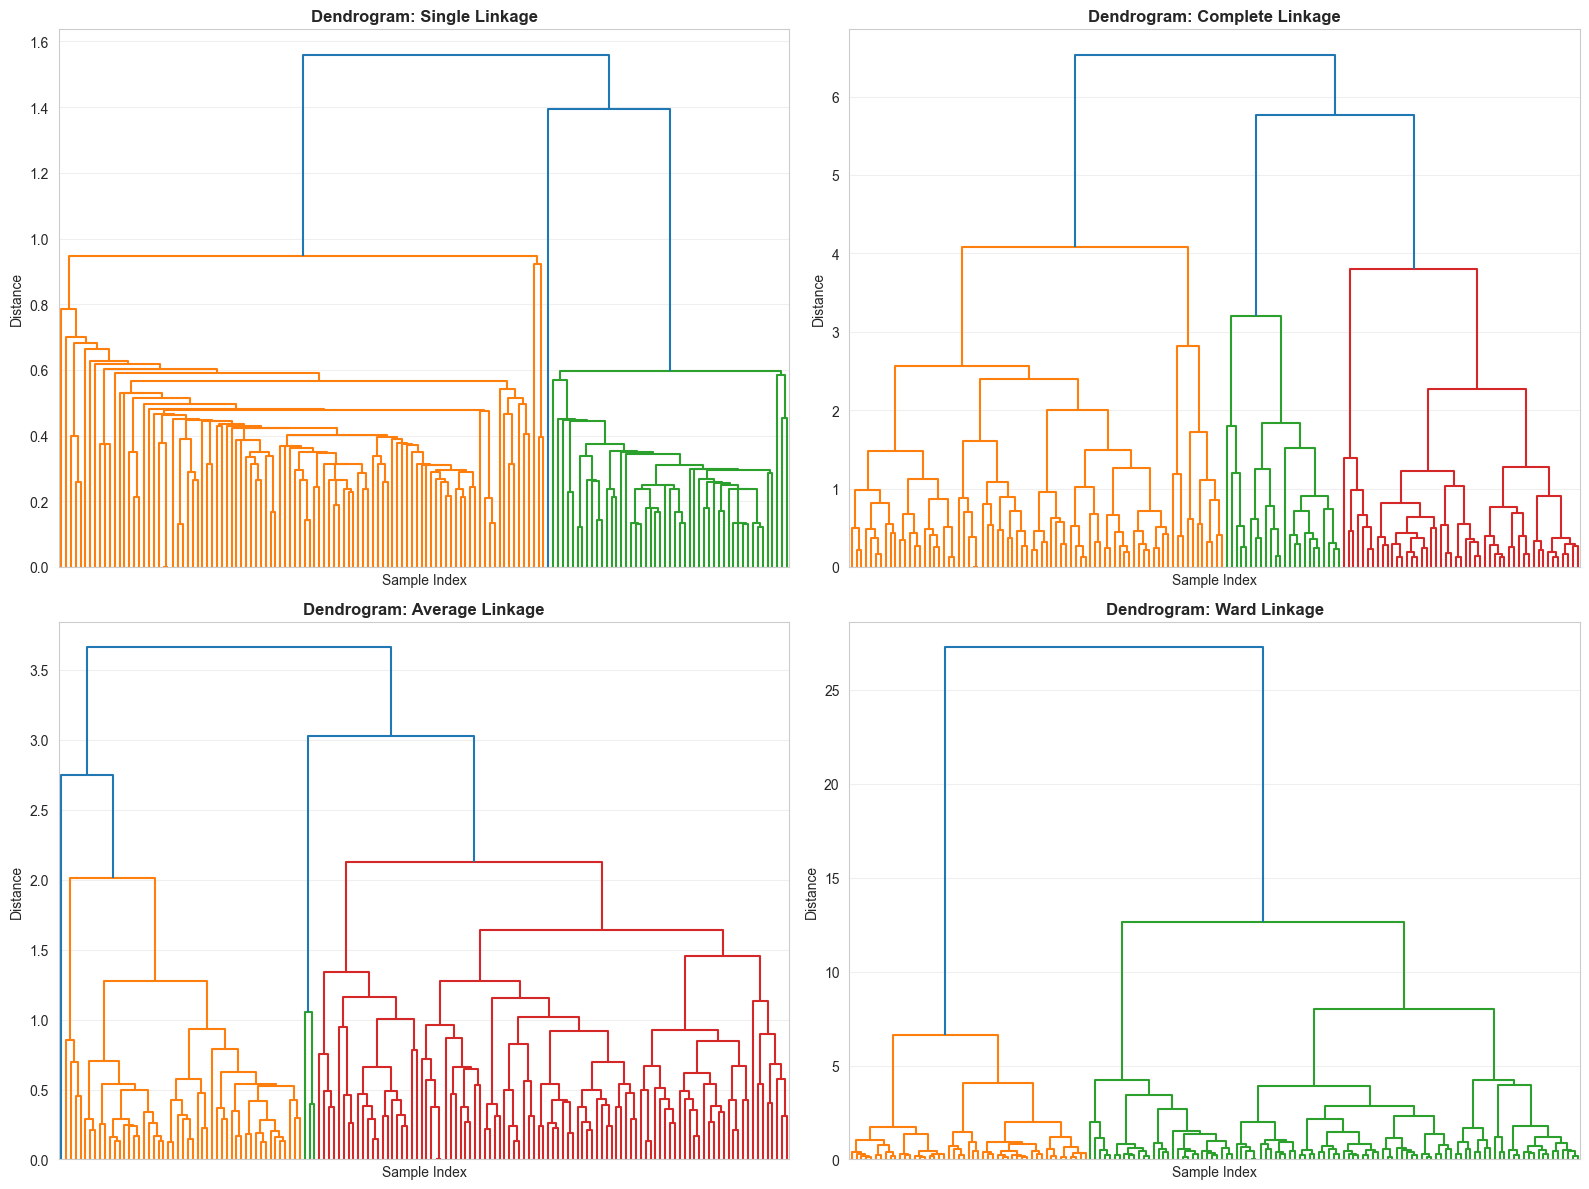

Linkage Methods Comparison:
- Single Linkage: Tends to create long chains (not ideal here)
- Complete Linkage: Creates more compact, well-separated clusters
- Average Linkage: Balanced approach, good middle ground
- Ward: Minimizes within-cluster variance (usually preferred)


In [24]:
# Compare different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    Z_method = linkage(X_scaled, method=method)
    dendrogram(Z_method, ax=axes[idx], no_labels=True)
    axes[idx].set_title(f'Dendrogram: {method.capitalize()} Linkage', fontweight='bold')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Linkage Methods Comparison:")
print("="*50)
print("- Single Linkage: Tends to create long chains (not ideal here)")
print("- Complete Linkage: Creates more compact, well-separated clusters")
print("- Average Linkage: Balanced approach, good middle ground")
print("- Ward: Minimizes within-cluster variance (usually preferred)")

---
## Summary and Comparison

### Quick Comparison Table

| Aspect | Logistic Regression | KNN | K-Means | Hierarchical |
|--------|-------------------|-----|---------|---------------|
| **Type** | Supervised | Supervised | Unsupervised | Unsupervised |
| **Learning** | Linear separator | Instance-based | Centroid-based | Linkage-based |
| **Training Time** | Fast | None (lazy) | Fast to moderate | Slow |
| **Prediction Time** | Very fast | Slow | Fast | N/A |
| **Requires k** | No | Yes (neighbors) | Yes (clusters) | Yes (for cutting) |
| **Interpretability** | High | Medium | High | Very High |
| **Works with** | Labeled data | Labeled data | Unlabeled data | Unlabeled data |
| **Best for** | Linear problems | Non-linear | Exploratory | Hierarchies |

### When to Use Each Technique

**Choose Logistic Regression if:**
- You have labeled training data (supervised learning)
- You need fast predictions
- You want interpretable results
- Your problem is approximately linear
- You need probability estimates

**Choose KNN if:**
- You have labeled training data
- Your problem is non-linear
- Dataset is small to medium-sized
- Features are properly scaled
- Prediction speed is not critical

**Choose K-Means if:**
- You want to discover natural groupings (unsupervised)
- You have unlabeled data
- Need scalability to large datasets
- Clusters are roughly spherical
- You can determine optimal k

**Choose Hierarchical Clustering if:**
- You want visual hierarchy of clusters
- You're exploring data structure
- Need flexible cluster level selection
- Dataset is not too large (< 10,000 points)
- Want dendrogram visualization

### Key Takeaways

1. **Supervised vs Unsupervised:** Supervised (LR, KNN) work with labels; Unsupervised (K-Means, HC) discover patterns
2. **Linear vs Non-linear:** Logistic Regression is linear; KNN, K-Means, HC are non-linear
3. **Feature Scaling:** Essential for distance-based algorithms (KNN, K-Means, HC); important for Logistic Regression
4. **No Free Lunch:** No single "best" algorithm; choice depends on your specific problem
5. **Always Explore:** Use visualizations and multiple methods to understand your data

### Practice Exercises

1. **Experiment with parameters:** Try different k values for KNN, different numbers of clusters for K-Means
2. **Use different datasets:** Explore how these algorithms perform on other datasets
3. **Feature engineering:** Test how different features affect model performance
4. **Combine methods:** Use clustering results as features for classification
5. **Evaluate thoroughly:** Always check both training and test performance

In [25]:
# Final Summary: Algorithm Performance on Iris Dataset
print("\n" + "="*70)
print(" "*15 + "FINAL SUMMARY: ALGORITHM PERFORMANCE")
print("="*70)

print("\n1. SUPERVISED LEARNING (Classification)")
print("-" * 70)
print(f"\nLogistic Regression:")
print(f"  Training Accuracy: {train_accuracy_lr:.4f}")
print(f"  Testing Accuracy:  {test_accuracy_lr:.4f}")
print(f"\nK-Nearest Neighbors (k={optimal_k}):")
print(f"  Training Accuracy: {train_accuracy_knn:.4f}")
print(f"  Testing Accuracy:  {test_accuracy_knn:.4f}")

print("\n2. UNSUPERVISED LEARNING (Clustering)")
print("-" * 70)
from sklearn.metrics import silhouette_score
sil_kmeans = silhouette_score(X_scaled, kmeans_clusters)
sil_hierarchical = silhouette_score(X_scaled, hierarchical_clusters)
print(f"\nK-Means (k=3):")
print(f"  Silhouette Score: {sil_kmeans:.4f}")
print(f"  Inertia: {kmeans_model.inertia_:.2f}")
print(f"\nHierarchical Clustering (k=3, Ward linkage):")
print(f"  Silhouette Score: {sil_hierarchical:.4f}")

print("\n3. KEY INSIGHTS")
print("-" * 70)
print(f"✓ Both KNN and Logistic Regression achieve high accuracy on Iris dataset")
print(f"✓ KNN slightly outperforms Logistic Regression ({test_accuracy_knn:.1%} vs {test_accuracy_lr:.1%})")
print(f"✓ K-Means and Hierarchical Clustering successfully recover the 3 iris species")
print(f"✓ All algorithms benefit from feature standardization")
print(f"\n" + "="*70)


               FINAL SUMMARY: ALGORITHM PERFORMANCE

1. SUPERVISED LEARNING (Classification)
----------------------------------------------------------------------

Logistic Regression:
  Training Accuracy: 0.9667
  Testing Accuracy:  0.9833

K-Nearest Neighbors (k=3):
  Training Accuracy: 0.9444
  Testing Accuracy:  0.9833

2. UNSUPERVISED LEARNING (Clustering)
----------------------------------------------------------------------

K-Means (k=3):
  Silhouette Score: 0.4599
  Inertia: 139.82

Hierarchical Clustering (k=3, Ward linkage):
  Silhouette Score: 0.4467

3. KEY INSIGHTS
----------------------------------------------------------------------
✓ Both KNN and Logistic Regression achieve high accuracy on Iris dataset
✓ KNN slightly outperforms Logistic Regression (98.3% vs 98.3%)
✓ K-Means and Hierarchical Clustering successfully recover the 3 iris species
✓ All algorithms benefit from feature standardization

